# Labyrinth Forge - Neural Ensemble Verification
This notebook verifies the 3 models (Isolation Forest, XGBoost, and Frustration Regressor) using the generated dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ml_ensemble import ensemble, FEATURE_NAMES

# 1. Load the generated dataset
df = pd.read_csv('datasets/behavioral_fingerprints.csv')
print(f"Dataset loaded: {df.shape[0]} samples")
df.head()

Dataset loaded: 1000 samples


,avg_keystroke_delay_ms,typing_speed_wpm,error_rate_pct,command_diversity,session_duration_s,unique_commands,dangerous_cmd_ratio,time_between_commands_ms,backspace_frequency,paste_frequency,label,label_name,frustration_index
0,0.000000,99.606971,14.893273,0.549164,1110.040473,18.0,0.251935,1056.276632,0.217540,0.386646,1,Malicious_Hacker,68.263875
1,94.381438,84.934581,9.797950,0.345541,609.043920,34.0,0.288564,1294.664024,0.205501,0.403137,1,Malicious_Hacker,86.382091
2,52.095342,120.998420,20.704295,0.144940,575.486792,25.0,0.312058,399.820627,0.143725,0.211852,1,Malicious_Hacker,98.731727
3,54.860572,71.253795,16.572254,0.181865,476.295992,36.0,0.175213,307.233876,0.146525,0.450689,1,Malicious_Hacker,87.225862
4,116.260737,63.287255,6.112460,0.923130,2722.759151,8.0,0.039923,3764.105296,0.070383,0.079426,0,Benign_Admin,31.907461


In [2]:
# 2. Train the ensemble
results = ensemble.train_all()
eval_data = results['evaluation']


  LABYRINTH FORGE — NEURAL ENSEMBLE TRAINING
  [+] Loaded dataset from CSV: c:\Users\SUMAN. S\Desktop\ENGINERING\Labrynth Forge\LABYRINTH-FORGE\backend\datasets\behavioral_fingerprints.csv  (1000 samples)

[1/3] Isolation Forest (Unsupervised Anomaly Detection)
  Epoch  1/10  Trees:  10  Acc:  75.50%
  Epoch  2/10  Trees:  20  Acc:  75.00%
  Epoch  3/10  Trees:  30  Acc:  78.50%
  Epoch  4/10  Trees:  40  Acc:  76.50%
  Epoch  5/10  Trees:  50  Acc:  74.00%
  Epoch  6/10  Trees:  60  Acc:  72.50%
  Epoch  7/10  Trees:  70  Acc:  73.00%
  Epoch  8/10  Trees:  80  Acc:  73.50%
  Epoch  9/10  Trees:  90  Acc:  73.50%
  Epoch 10/10  Trees: 100  Acc:  74.00%
  [+] Isolation Forest: Acc=74.00%  Prec=88.71%  Rec=55.00%  F1=67.90%

[2/3] Gradient Boosting Classifier (XGBoost-style)
  Epoch  1/10  Est:  10  Acc:  99.50%  Loss: 0.0050
  Epoch  2/10  Est:  20  Acc:  99.50%  Loss: 0.0050
  Epoch  3/10  Est:  30  Acc:  99.50%  Loss: 0.0050
  Epoch  4/10  Est:  40  Acc:  99.50%  Loss: 0.0050
  Epoc

## 3. Visualization: Model Accuracies

## 4. Confusion Matrix (XGBoost)

In [ ]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))
cm = eval_data['xgboost']['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malicious'], 
            yticklabels=['Benign', 'Malicious'])
plt.title('Confusion Matrix: XGBoost Attack Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

C:\Users\SUMAN. S\AppData\Local\Temp\ipykernel_31044\3721902987.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


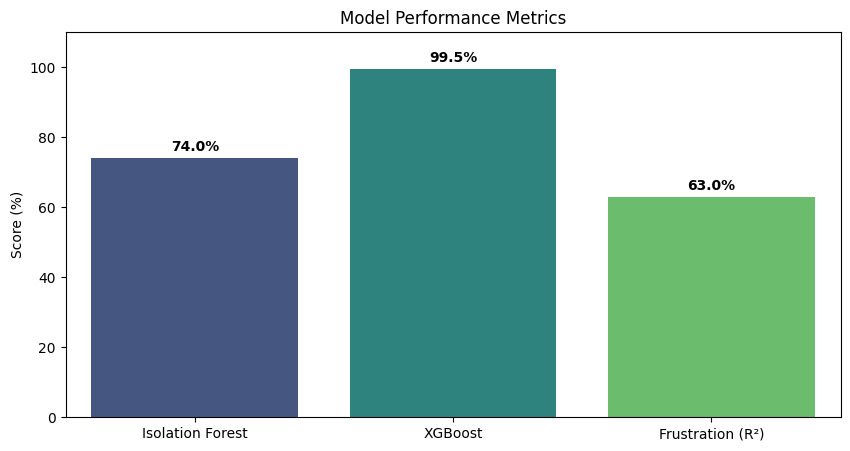

In [3]:
accuracies = {
    'Isolation Forest': eval_data['isolation_forest']['accuracy'],
    'XGBoost': eval_data['xgboost']['accuracy'],
    'Frustration (R²)': eval_data['frustration_regressor']['r2_score']
}

plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')
plt.title('Model Performance Metrics')
plt.ylabel('Score (%)')
plt.ylim(0, 110)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 2, f"{v}%", ha='center', fontweight='bold')
plt.show()

## 5. Feature Importance (XGBoost)

C:\Users\SUMAN. S\AppData\Local\Temp\ipykernel_31044\1171475986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=imp_df, palette='magma')


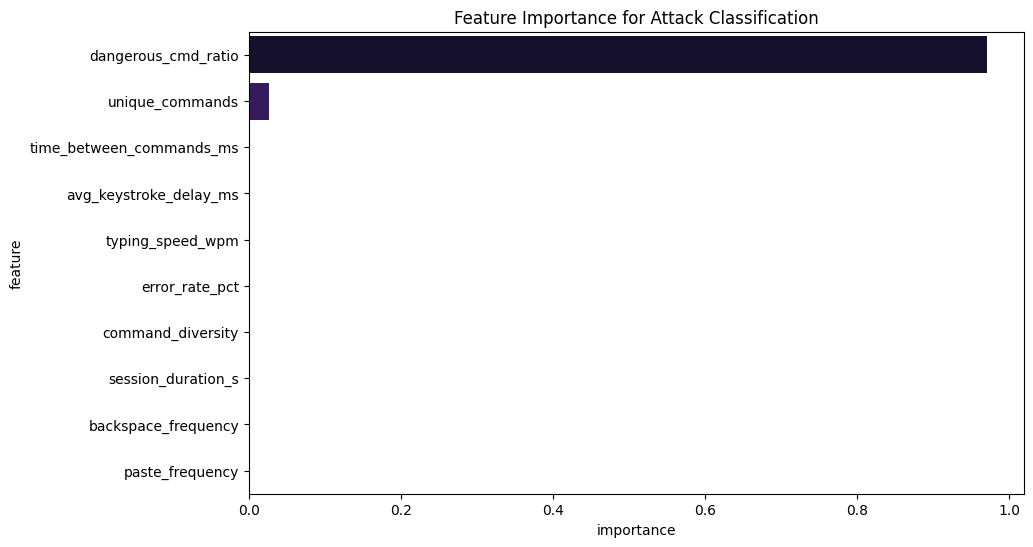

In [4]:
imp_df = pd.DataFrame(eval_data['xgboost']['feature_importance'])
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=imp_df, palette='magma')
plt.title('Feature Importance for Attack Classification')
plt.show()

## 6. Live Prediction Test

In [5]:
test_attacker = {
    'avg_keystroke_delay_ms': 50,
    'typing_speed_wpm': 120,
    'error_rate_pct': 25,
    'command_diversity': 0.15,
    'session_duration_s': 200,
    'unique_commands': 40,
    'dangerous_cmd_ratio': 0.6,
    'time_between_commands_ms': 500,
    'backspace_frequency': 0.35,
    'paste_frequency': 0.5
}

prediction = ensemble.predict(test_attacker)
print(f"Anomaly Detected (IF): {prediction['isolation_forest']['is_anomaly']}")
print(f"Malicious Prob (XGB): {prediction['xgboost']['malicious_prob']}%")
print(f"Frustration Index:    {prediction['frustration_index']}/100")
print(f"Defense Action:       {prediction['tarpit_action']}")

Anomaly Detected (IF): True
Malicious Prob (XGB): 100.0%
Frustration Index:    76.71/100
Defense Action:       Leaking fake credentials to maximize intel before disconnect
